In [5]:
import pandas as pd
df = pd.read_csv("../data/Loan_default.csv")
df.shape
df.columns
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [6]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.isnull().sum().sum()
(df.isnull().sum() / len(df)) * 100

LoanID            0.0
Age               0.0
Income            0.0
LoanAmount        0.0
CreditScore       0.0
MonthsEmployed    0.0
NumCreditLines    0.0
InterestRate      0.0
LoanTerm          0.0
DTIRatio          0.0
Education         0.0
EmploymentType    0.0
MaritalStatus     0.0
HasMortgage       0.0
HasDependents     0.0
LoanPurpose       0.0
HasCoSigner       0.0
Default           0.0
dtype: float64

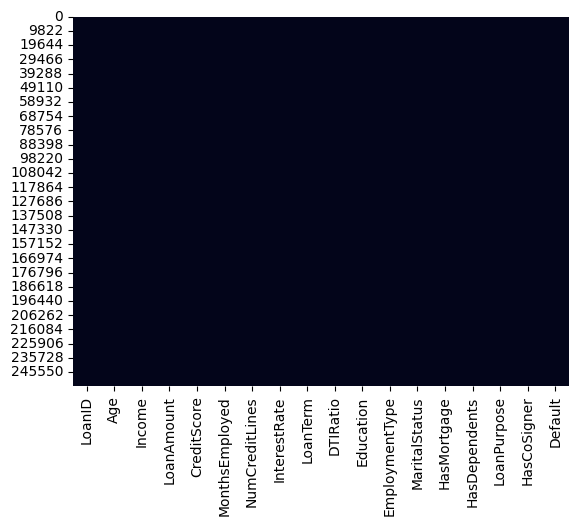

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [11]:
df.duplicated().sum()
df.columns
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [12]:
df.dtypes

LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

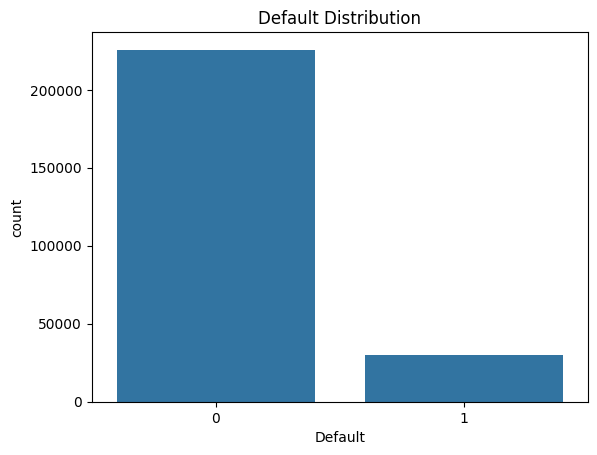

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Default", data=df)
plt.title("Default Distribution")
plt.show()

In [14]:
df.drop("LoanID", axis=1, inplace=True)

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
df.head()
df.shape
df.dtypes

Age                               int64
Income                            int64
LoanAmount                        int64
CreditScore                       int64
MonthsEmployed                    int64
NumCreditLines                    int64
InterestRate                    float64
LoanTerm                          int64
DTIRatio                        float64
Default                           int64
Education_High School              bool
Education_Master's                 bool
Education_PhD                      bool
EmploymentType_Part-time           bool
EmploymentType_Self-employed       bool
EmploymentType_Unemployed          bool
MaritalStatus_Married              bool
MaritalStatus_Single               bool
HasMortgage_Yes                    bool
HasDependents_Yes                  bool
LoanPurpose_Business               bool
LoanPurpose_Education              bool
LoanPurpose_Home                   bool
LoanPurpose_Other                  bool
HasCoSigner_Yes                    bool


In [18]:
df = df.astype(int)
df.dtypes

Age                             int64
Income                          int64
LoanAmount                      int64
CreditScore                     int64
MonthsEmployed                  int64
NumCreditLines                  int64
InterestRate                    int64
LoanTerm                        int64
DTIRatio                        int64
Default                         int64
Education_High School           int64
Education_Master's              int64
Education_PhD                   int64
EmploymentType_Part-time        int64
EmploymentType_Self-employed    int64
EmploymentType_Unemployed       int64
MaritalStatus_Married           int64
MaritalStatus_Single            int64
HasMortgage_Yes                 int64
HasDependents_Yes               int64
LoanPurpose_Business            int64
LoanPurpose_Education           int64
LoanPurpose_Home                int64
LoanPurpose_Other               int64
HasCoSigner_Yes                 int64
dtype: object

In [21]:
df["Loan_Income_Ratio"] = df["LoanAmount"] / df["Income"]
df[["LoanAmount", "Income", "Loan_Income_Ratio"]].head()

,LoanAmount,Income,Loan_Income_Ratio
0,50587,85994,0.588262
1,124440,50432,2.467481
2,129188,84208,1.534154
3,44799,31713,1.412638
4,9139,20437,0.447179


In [24]:
df["Estimated_EMI"] = df["LoanAmount"] / df["LoanTerm"]
df["EMI_Income_Ratio"] = df["Estimated_EMI"] / df["Income"]
df[["Estimated_EMI", "EMI_Income_Ratio"]].head()

,Estimated_EMI,EMI_Income_Ratio
0,1405.194444,0.016341
1,2074.000000,0.041125
2,5382.833333,0.063923
3,1866.625000,0.058860
4,190.395833,0.009316


In [32]:
df["Income_Group"] = pd.cut(
    df["Income"],
    bins=3,
    labels=["Low Income", "Medium Income", "High Income"]
)

In [33]:
df = pd.get_dummies(df, columns=["Income_Group"], drop_first=True)

In [34]:
df.shape

(255347, 34)

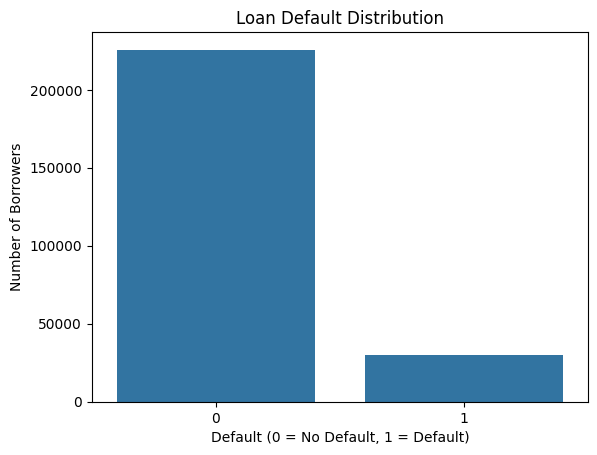

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Default", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Number of Borrowers")

plt.show()

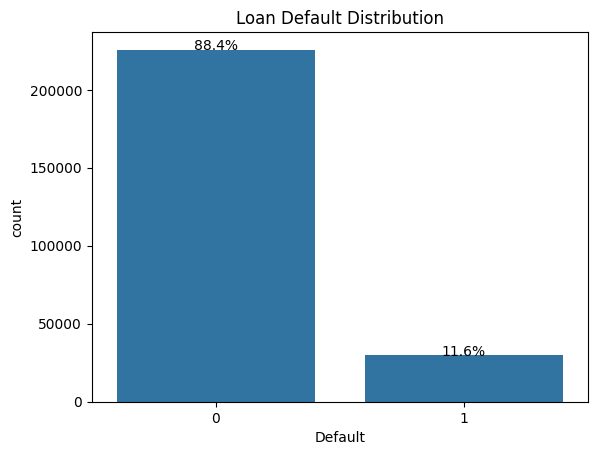

In [36]:
sns.countplot(x="Default", data=df)

total = len(df)

for p in plt.gca().patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    plt.text(x, y, percentage, ha="center")

plt.title("Loan Default Distribution")
plt.show()

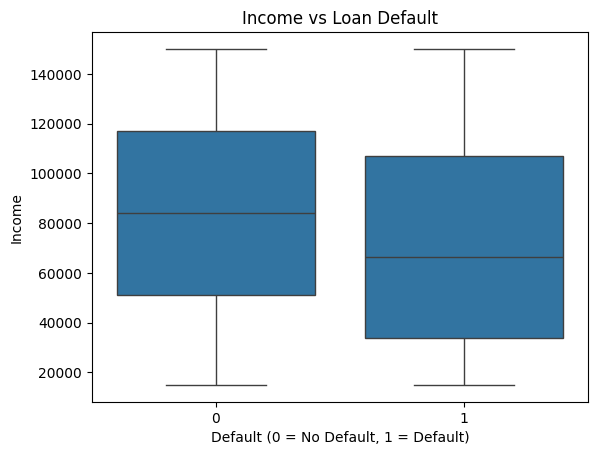

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="Default", y="Income", data=df)

plt.title("Income vs Loan Default")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Income")

plt.show()

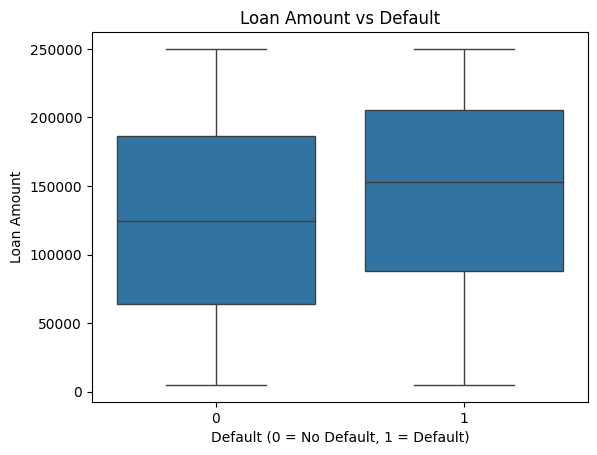

In [38]:
plt.figure()
sns.boxplot(x="Default", y="LoanAmount", data=df)

plt.title("Loan Amount vs Default")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Loan Amount")

plt.show()

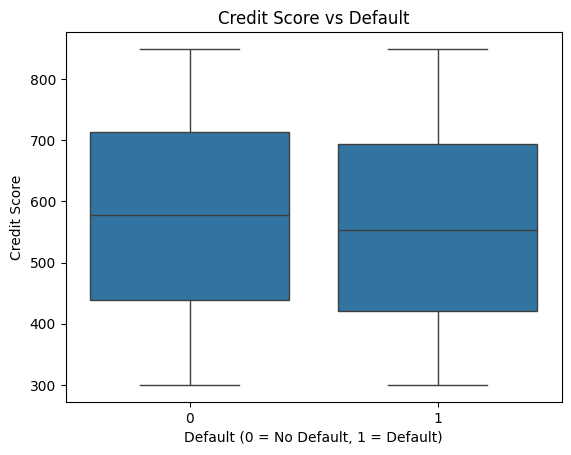

In [39]:
plt.figure()
sns.boxplot(x="Default", y="CreditScore", data=df)

plt.title("Credit Score vs Default")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Credit Score")

plt.show()

In [40]:
corr_matrix = df.corr()
corr_matrix

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasCoSigner_Yes,Loan_Income_Ratio,Estimated_EMI,EMI_Income_Ratio,Income_Group_Medium Income,Income_Group_High Income,Income_Group_Medium Income,Income_Group_High Income,Income_Group_Medium Income,Income_Group_High Income
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001086,0.000263,NaN,-0.167783,...,-0.002918,-0.000343,-0.001054,-0.000235,0.003911,-0.003385,0.003911,-0.003385,0.003911,-0.003385
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002143,-0.000998,NaN,-0.099119,...,-0.003524,-0.613392,-0.001626,-0.456256,-0.000549,0.816581,-0.000549,0.816581,-0.000549,0.816581
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002364,0.002538,NaN,0.086659,...,-0.001848,0.554730,0.606728,0.412459,0.001487,-0.000825,0.001487,-0.000825,0.001487,-0.000825
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000511,0.001130,NaN,-0.034166,...,-0.002755,-0.000171,-0.001102,-0.000918,0.001764,-0.002258,0.001764,-0.002258,0.001764,-0.002258
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000150,-0.001166,NaN,-0.097374,...,0.001045,-0.001630,0.002388,-0.000922,0.002389,0.000881,0.002389,0.000881,0.002389,0.000881
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000316,-0.000226,NaN,0.028330,...,0.002105,0.000008,0.000937,0.001575,-0.001087,-0.001273,-0.001087,-0.001273,-0.001087,-0.001273
InterestRate,-0.001086,-0.002143,-0.002364,0.000511,0.000150,-0.000316,1.000000,0.000915,NaN,0.131244,...,-0.003939,-0.000754,-0.001383,0.000367,0.000927,-0.003215,0.000927,-0.003215,0.000927,-0.003215
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000915,1.000000,NaN,0.000545,...,-0.001166,0.002196,-0.625091,-0.425005,-0.000345,-0.000697,-0.000345,-0.000697,-0.000345,-0.000697
DTIRatio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131244,0.000545,NaN,1.000000,...,-0.039109,0.178963,0.053656,0.133822,-0.037540,-0.055825,-0.037540,-0.055825,-0.037540,-0.055825


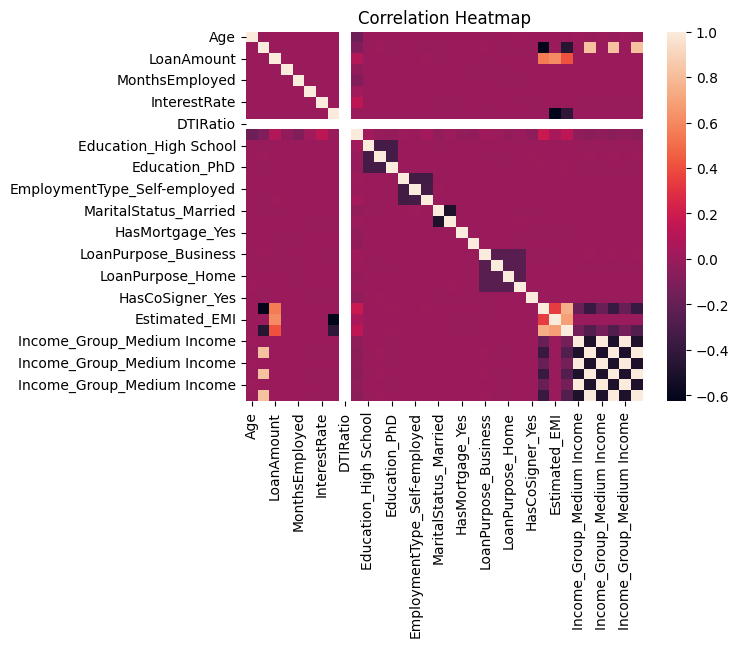

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr())

plt.title("Correlation Heatmap")
plt.show()

In [44]:
df.corr()["Default"].sort_values(ascending=False)

Default                         1.000000
Loan_Income_Ratio               0.178963
EMI_Income_Ratio                0.133822
InterestRate                    0.131244
LoanAmount                      0.086659
Estimated_EMI                   0.053656
EmploymentType_Unemployed       0.034957
NumCreditLines                  0.028330
Education_High School           0.022831
LoanPurpose_Business            0.011162
MaritalStatus_Single            0.006607
EmploymentType_Part-time        0.006372
LoanPurpose_Education           0.003512
LoanPurpose_Other               0.002737
LoanTerm                        0.000545
EmploymentType_Self-employed   -0.002714
Education_Master's             -0.013314
Education_PhD                  -0.018447
LoanPurpose_Home               -0.021564
HasMortgage_Yes                -0.022856
MaritalStatus_Married          -0.026875
CreditScore                    -0.034166
HasDependents_Yes              -0.034678
Income_Group_Medium Income     -0.037540
Income_Group_Med

In [45]:
X = df.drop("Default", axis=1)
y = df["Default"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [47]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(51070,)

In [48]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (204277, 33)
Testing set size: (51070, 33)


In [51]:
from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [52]:
y_pred_dummy = dummy_model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
print("Baseline Accuracy:", accuracy_dummy)

Baseline Accuracy: 0.8844722929312708


In [54]:
from sklearn.metrics import confusion_matrix

cm_dummy = confusion_matrix(y_test, y_pred_dummy)
print("Confusion Matrix:\n", cm_dummy)

Confusion Matrix:
 [[45170     0]
 [ 5900     0]]


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45170
           1       0.00      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



c:\Users\avnip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\avnip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\avnip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [75]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

c:\Users\avnip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
y_prob = log_model.predict_proba(X_test)[:, 1]
y_prob[:5]

array([0.0380262 , 0.04136034, 0.10876025, 0.09225933, 0.10326941])

In [68]:
y_prob_default = log_model.predict_proba(X_test)[:,1]
y_prob_default[:10]

array([0.0380262 , 0.04136034, 0.10876025, 0.09225933, 0.10326941,
       0.1186204 , 0.04089637, 0.04965911, 0.02906888, 0.11541541])

In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[44890   280]
 [ 5491   409]]


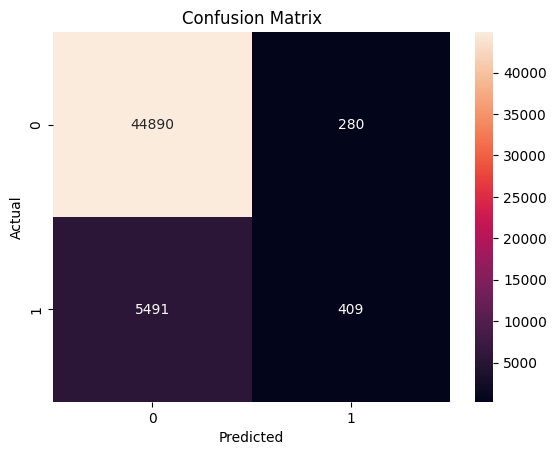

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.59      0.07      0.12      5900

    accuracy                           0.89     51070
   macro avg       0.74      0.53      0.53     51070
weighted avg       0.86      0.89      0.85     51070



In [81]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc) 

ROC-AUC Score: 0.7496859885254574


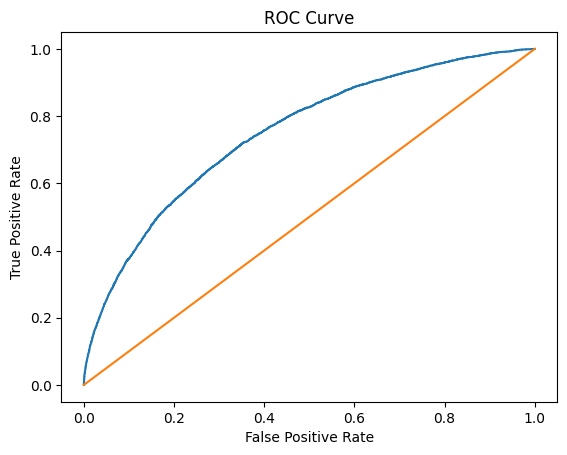

In [82]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # diagonal line (random model)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [85]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df.head()

,Feature,Coefficient
0,Age,-4.540128e-02
1,Income,-1.958653e-06
2,LoanAmount,1.194981e-07
3,CreditScore,-1.262547e-03
4,MonthsEmployed,-1.163844e-02


In [86]:
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
coef_df.head(10)   # top positive predictors

,Feature,Coefficient
24,Loan_Income_Ratio,0.193080
6,InterestRate,0.061228
5,NumCreditLines,0.041078
14,EmploymentType_Unemployed,0.025065
32,Income_Group_High Income,0.016711
30,Income_Group_High Income,0.016711
28,Income_Group_High Income,0.016711
9,Education_High School,0.014446
19,LoanPurpose_Business,0.007381
26,EMI_Income_Ratio,0.007242


In [87]:
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
24,Loan_Income_Ratio,0.193080,0.193080
6,InterestRate,0.061228,0.061228
0,Age,-0.045401,0.045401
5,NumCreditLines,0.041078,0.041078
23,HasCoSigner_Yes,-0.036046,0.036046
18,HasDependents_Yes,-0.031346,0.031346
14,EmploymentType_Unemployed,0.025065,0.025065
27,Income_Group_Medium Income,-0.022034,0.022034
31,Income_Group_Medium Income,-0.022034,0.022034
29,Income_Group_Medium Income,-0.022034,0.022034


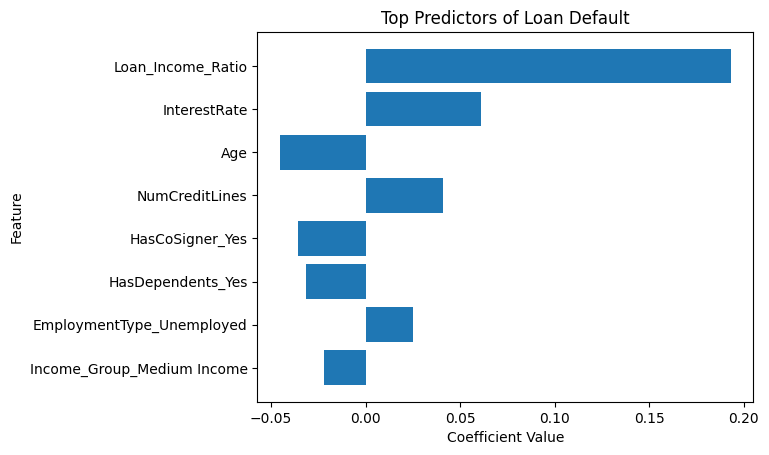

In [88]:
import matplotlib.pyplot as plt

top_features = coef_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Predictors of Loan Default")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

In [89]:
df_test = X_test.copy()
df_test["Actual"] = y_test.values
df_test["Default_Probability"] = y_prob

In [91]:
import pandas as pd

df_test["Risk_Category"] = pd.cut(
    df_test["Default_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)
df_test[["Default_Probability", "Risk_Category"]].head(10)

,Default_Probability,Risk_Category
51139,0.038026,Low
71005,0.041360,Low
35684,0.108760,Low
174087,0.092259,Low
137952,0.103269,Low
137678,0.118620,Low
74249,0.040896,Low
253344,0.049659,Low
219115,0.029069,Low
144898,0.115415,Low


In [92]:
df_test["Risk_Category"].value_counts()

Risk_Category
Low       47523
Medium     3244
High        303
Name: count, dtype: int64